# 04 — Shapley, Aumann–Shapley, functional ANOVA, and SHAP

**Graduate course: Decomposition Analysis in Python**

## Learning objectives

- Implement exact Shapley values.
- Relate efficiency and symmetry to attribution.
- Separate predictive attribution from causal attribution.

## Roadmap and notation

### Guiding question

When several factors interact, what principled rule can allocate a total change or model prediction among them?

### Prerequisites

Sets and averages. Knowledge of machine learning is useful only for the SHAP section.

### Symbols

- $N=\{1,\ldots,p\}$: all players or features.
- $S\subseteq N$: coalition already present.
- $v(S)$: value produced by coalition $S$.
- $v(S\cup\{j\})-v(S)$: marginal contribution of player $j$ after $S$.
- $\phi_j$: Shapley allocation to player $j$.

We begin with an exact business identity. Only afterward do we map the same allocation logic to model explanations, where the definition of $v(S)$ becomes a substantive modeling choice.

## Cooperative-game allocation

For value function $v(S)$ and $p$ players,
$$\phi_j=\sum_{S\subseteq N\setminus\{j\}}\frac{|S|!(p-|S|-1)!}{p!}[v(S\cup\{j\})-v(S)].$$
The allocation is efficient, symmetric, additive, and assigns zero to null players. Aumann–Shapley is a continuous-path analogue. Functional ANOVA decomposes a square-integrable function into main and interaction functions relative to an input distribution.

SHAP applies Shapley values to model predictions. The coalition value depends on a background distribution and on whether “missing” features are integrated conditionally or interventionally. Therefore a SHAP value is a model-and-background-specific predictive attribution, not automatically a causal effect.

## Conditional, marginal, and causal games

For a prediction model $f$ and explained point $x$, common coalition games include

$$v_{\text{cond}}(S)=E[f(X)\mid X_S=x_S],$$

and

$$v_{\text{marg}}(S)=E_{X_{-S}}[f(x_S,X_{-S})].$$

The conditional game respects observed dependence but may assign credit to a feature unused by $f$ through correlation. The marginal/interventional game breaks dependence and can evaluate unrealistic combinations. A causal game would instead be defined from an SCM, for example $v_{\text{causal}}(S)=E[Y\mid do(X_S=x_S)]$; it is a different estimand, not a switch in plotting software.

Computing exact Shapley values costs $O(2^p)$ coalition evaluations (or $p!$ paths); practical SHAP methods exploit model structure or Monte Carlo approximation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from itertools import permutations, combinations
pd.options.display.float_format = '{:,.4f}'.format
plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)

In [2]:
features=['traffic','conversion','price']
base={'traffic':1000.,'conversion':.04,'price':50.}; current={'traffic':1200.,'conversion':.05,'price':48.}
def revenue(z): return z['traffic']*z['conversion']*z['price']
def value(S):
    z={k:(current[k] if k in S else base[k]) for k in features}; return revenue(z)-revenue(base)
phi={j:0. for j in features}
for order in permutations(features):
    S=set()
    for j in order:
        phi[j]+=(value(S|{j})-value(S))/__import__("math").factorial(len(features)); S.add(j)
pd.Series({**phi,'allocated':sum(phi.values()),'observed':revenue(current)-revenue(base)})

traffic      440.6667
conversion   538.6667
price        -99.3333
allocated    880.0000
observed     880.0000
dtype: float64

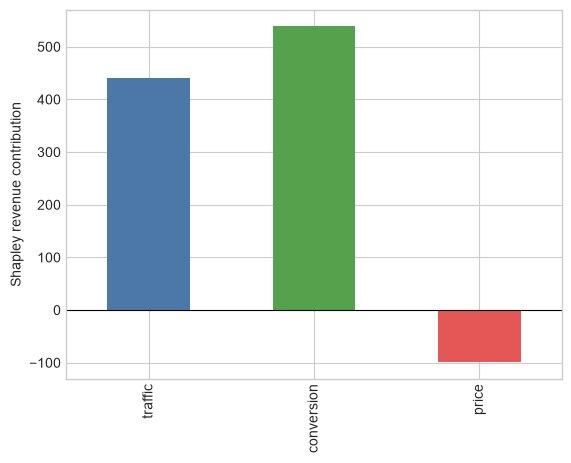

In [3]:
pd.Series(phi).plot.bar(color=['#4C78A8','#54A24B','#E45756']); plt.axhline(0,color='black',lw=.8); plt.ylabel('Shapley revenue contribution'); plt.show()

## Reading the worked example

Revenue increases by 880. Shapley allocates +440.67 to traffic, +538.67 to conversion, and −99.33 to price. `allocated = observed` verifies efficiency. The negative price contribution reflects the fall from 50 to 48; it does not estimate price elasticity.

Why is this preferable to one arbitrary replacement order? Every possible order is averaged, so interaction credit is shared symmetrically. The later baseline-sensitivity table shows that symmetry does not make the answer baseline-free.

## Growth-marketing case: churn and conversion models

Use SHAP to debug a fitted churn or conversion model, detect leakage, compare segments, and explain why the model scored a user highly. Do not use it to rank budget interventions unless the model and coalition game encode the intervention process.

Examples of traps:

- `discount_seen` is post-treatment and can dominate prediction without being an actionable cause.
- channel and geography are correlated; conditional and marginal SHAP answer different questions.
- aggregating $|\phi_j|$ hides direction and can favor high-cardinality/noisy features.
- background data from last quarter makes attribution drift when the user mix changes.

In [4]:
# Baseline sensitivity of the revenue Shapley allocation
def shapley_between(baseline, target):
    def v(S):
        z={k:(target[k] if k in S else baseline[k]) for k in features}
        return revenue(z)-revenue(baseline)
    out={j:0. for j in features}
    orders=list(permutations(features))
    for order in orders:
        S=set()
        for j in order:
            out[j]+=(v(S|{j})-v(S))/len(orders); S.add(j)
    return out
alt={'traffic':900.,'conversion':.045,'price':52.}
pd.DataFrame({'original baseline':shapley_between(base,current),
              'alternative baseline':shapley_between(alt,current)})

,original baseline,alternative baseline
traffic,440.6667,712.0000
conversion,538.6667,262.0000
price,-99.3333,-200.0000


## Limitations and robustness

- Attribution is model-specific; a misspecified or poorly calibrated model can be explained perfectly.
- Results depend on baseline/background distribution and missing-feature semantics.
- Correlated features make credit allocation scientifically ambiguous.
- Exactness/efficiency does not imply stability; report Monte Carlo error and variation across folds/seeds/background samples.
- Global mean absolute SHAP is not a causal elasticity and not necessarily useful for intervention.
- Functional ANOVA orthogonality depends on the input measure; dependent inputs complicate uniqueness.
- Validate predictive performance out of sample, test leakage, group collinear features, and compare conditional versus marginal games.

## What came next

**Lundberg & Lee (2017)** connected additive feature attribution to Shapley values. **Lundberg et al. (2020)** developed TreeSHAP-based explanations for tree ensembles. **Aas, Jullum & Løland (2021)** addressed dependent features with conditional distributions. **Sundararajan & Najmi (2020)** clarified the many distinct “Shapley” games, while **Heskes et al. (2020)** and related work developed causal Shapley values using explicit causal structure.

## Takeaways and bridge to Notebook 05

1. Shapley values solve an allocation problem once the game $v(S)$ is fixed.
2. Efficiency and symmetry do not remove baseline or model dependence.
3. SHAP explains predictions under a chosen missing-feature semantics.
4. Predictive attribution is not intervention effect.

Notebook 05 completes the course by defining the additional assumptions and research designs needed for causal claims.

### Exercise

Change the baseline and recompute. Which axioms remain true? Why does baseline sensitivity weaken any claim that a contribution is intrinsic?

## Interpretation checklist

1. State the mathematical identity or estimand.
2. Verify exactness numerically.
3. Separate description, prediction, and causation.
4. Report reference population/path/order.
5. Quantify sampling uncertainty when inputs are estimated.

## References

- Shapley, L. S. (1953). A value for n-person games. In *Contributions to the Theory of Games II*. Princeton University Press.
- Aumann, R. J., & Shapley, L. S. (1974). *Values of Non-Atomic Games*. Princeton University Press.
- Hoeffding, W. (1948). A class of statistics with asymptotically normal distribution. *Annals of Mathematical Statistics*, 19, 293–325.
- Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. *NeurIPS 30*, 4765–4774. https://papers.nips.cc/paper/7062
- Lundberg, S. M. et al. (2020). From local explanations to global understanding with explainable AI for trees. *Nature Machine Intelligence*, 2, 56–67. https://doi.org/10.1038/s42256-019-0138-9
- Sundararajan, M., & Najmi, A. (2020). The many Shapley values for model explanation. *ICML 2020*, PMLR 119, 9269–9278. https://proceedings.mlr.press/v119/sundararajan20b.html
- Aas, K., Jullum, M., & Løland, A. (2021). Explaining individual predictions when features are dependent. *Artificial Intelligence*, 298, 103502. https://doi.org/10.1016/j.artint.2021.103502
- Heskes, T., Sijben, E., Bucur, I. G., & Claassen, T. (2020). Causal Shapley values: Exploiting causal knowledge to explain individual predictions of complex models. *NeurIPS 33*, 4778–4789.